# DNAS-1 · 이름과 사진을 DNA에 저장하기
- ACS Nano 원본의 `column_data → xor_data → nrsin → DNA_library` 흐름을 실습한다.
- 입력은 UTF-8 또는 파일 byte, RS 심볼은 **1 byte**, DNA 본문은 108 nt이다.
- 위에서 아래로 셀을 실행한다. 이름·채널 값을 바꾼 뒤 이후 셀을 다시 실행한다.
- [설명서](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html) · 인코딩 결과와 복호 결과를 CRC-32로 비교한다.

## 1. 준비
- Colab: 이 노트북을 열고 아래 셀을 실행한다. `dnastore.py`가 없으면 강의 사이트에서 내려받는다.
- 사이트 배포 전: `dnastore.py`를 Colab 파일 창에 업로드한다. 또는 그 내용을 새 코드 셀에 붙여넣고 첫 줄에 `%%writefile dnastore.py`를 넣어 실행한다.
- 로컬: `python/` 또는 프로젝트 루트에서 실행한다. 사진 셀만 Pillow를 사용한다.

In [1]:
from pathlib import Path
from io import BytesIO
from collections import defaultdict, Counter
import importlib.util
import json
import sys
import urllib.request
from IPython.display import display
from PIL import Image

BASE_URL = ("https://bbl.stdbioelec.com/courses/"
            "molecular-information-engineering/week04/dna-storage/")
candidates = [Path("dnastore.py"), Path("python/dnastore.py")]
module_path = next((p.resolve() for p in candidates if p.exists()), None)
if module_path is None:
    module_path = Path("dnastore.py").resolve()
    urllib.request.urlretrieve(BASE_URL + "python/dnastore.py", module_path)
sys.path.insert(0, str(module_path.parent))
import dnastore as ds

output_dir = module_path.parent / "lab_output"
output_dir.mkdir(exist_ok=True)
F = "AGCCTTGTGTCCATCAATCC"
R = "TGCGCTATGGTTTGGCTAAT"
BASES = "ATGC"
ROW_BYTES, NSYM, PAD = 17, 8, 0x1B
print("준비 완료: dnastore.py / 결과 폴더 lab_output/")

준비 완료: dnastore.py / 결과 폴더 lab_output/


## 2. 자기 이름
- 아래 문자열을 자기 이름으로 바꾼다. ASCII 이름과 한글 이름을 각각 비교한다.
- 원본 STL 읽기·분할 부분을 문자열의 UTF-8 변환으로 바꾼다.
- [입력 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#enc-input)

In [2]:
name = "송영준"
print("이름:", name)
print("글자 수:", len(name), "| ASCII만 사용:", name.isascii())

이름: 송영준
글자 수: 3 | ASCII만 사용: False


## 3. UTF-8 byte
- 코드포인트는 문자의 번호, UTF-8은 그 문자를 저장하는 byte 표현이다.
- ASCII 문자는 1 byte, 이 예제의 한글 음절은 각각 3 byte이다.

In [3]:
column_data = ds.text_bytes(name)  # 원본 column_data: 이제 bit 대신 byte.
print("글자   코드포인트   UTF-8 (16진수)")
for char in name:
    print(f"{char!r:5}  U+{ord(char):04X}       {char.encode('utf-8').hex(' ')}")
print("전체:", list(column_data))
print("파일 길이 L =", len(column_data), "byte")

글자   코드포인트   UTF-8 (16진수)
'송'    U+C1A1       ec 86 a1
'영'    U+C601       ec 98 81
'준'    U+C900       ec a4 80
전체: [236, 134, 161, 236, 152, 129, 236, 164, 128]
파일 길이 L = 9 byte


## 4. 헤더와 17 byte 행
- 1번 행은 원본 KIS에 해당한다. version, type, 길이, CRC, D, flags, 확장자를 담는다.
- 나머지 빈자리는 `0x1B → ATGC`로 채운다. 데이터 행 수 D는 짝수로 맞춘다.
- [행 나누기 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#enc-rows)

In [4]:
D = 1 + (len(column_data) + ROW_BYTES - 1) // ROW_BYTES
if D % 2:
    D += 1
header_row = (bytes([1, 1]) + len(column_data).to_bytes(4, "big")
              + ds.crc32(column_data).to_bytes(4, "big")
              + D.to_bytes(2, "big") + bytes([0]) + b"txt ")
padded = column_data.ljust((D - 1) * ROW_BYTES, bytes([PAD]))
rows = [header_row] + [padded[i:i + ROW_BYTES]
                       for i in range(0, len(padded), ROW_BYTES)]
print("D =", D, "| CRC-32 =", f"{ds.crc32(column_data):08X}")
for index, row in enumerate(rows, 1):
    print(index, "header" if index == 1 else "data", row.hex(" "))

D = 2 | CRC-32 = 1CBD87A9
1 header 01 01 00 00 00 09 1c bd 87 a9 00 02 00 74 78 74 20
2 data ec 86 a1 ec 98 81 ec a4 80 1b 1b 1b 1b 1b 1b 1b 1b


## 5. XOR 행
- 원본 `xor_A`는 앞 절반, `xor_B`는 뒤 절반이다. 행별 byte XOR로 `xor_data`를 만든다.
- `(A, B, A⊕B)` 중 하나가 없으면 나머지 두 행으로 복원한다.
- [XOR 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#enc-xor)

In [5]:
H = D // 2
xor_A, xor_B = rows[:H], rows[H:]
xor_data = [bytes(a ^ b for a, b in zip(left, right))
            for left, right in zip(xor_A, xor_B)]
stored_rows = rows + xor_data
for j, parity in enumerate(xor_data, 1):
    print(f"행 {j} XOR 행 {j + H} → 행 {D + j}: {parity.hex(' ')}")
print("전체 가닥 N = D + D/2 =", len(stored_rows))

행 1 XOR 행 2 → 행 3: ed 87 a1 ec 98 88 f0 19 07 b2 1b 19 1b 6f 63 6f 3b
전체 가닥 N = D + D/2 = 3


## 6. RS(27, 19) 부호어
- 원본 `nrsin = [resh_data index]`에 대응: 행 17 byte 뒤에 index 2 byte를 붙인다.
- GF(256), 원시 다항식 `0x11D`, 첫 근 `α¹`. 메시지 19 byte에 패리티 8 byte를 붙인다.
- 최대 4 byte 오류를 정정한다. 1 nt는 한 byte 안에 있으므로 **치환 4 nt**를 정정할 수 있다. 다만 index 오류에 따른 묶음 분류 실패는 별도 문제이다.
- [RS 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#enc-rs)

In [6]:
nrsin = [row + index.to_bytes(2, "big")
         for index, row in enumerate(stored_rows, 1)]
codewords = [ds.rs_encode(msg, NSYM) for msg in nrsin]
for index, cw in enumerate(codewords, 1):
    print(f"{index}: data={cw[:17].hex(' ')}")
    print(f"   index={cw[17:19].hex(' ')} | RS={cw[19:].hex(' ')}")
print("SONG 검산 패리티:", list(ds.rs_encode(b"SONG", 4)[4:]))

1: data=01 01 00 00 00 09 1c bd 87 a9 00 02 00 74 78 74 20
   index=00 01 | RS=6e ee 66 95 98 42 e5 d8
2: data=ec 86 a1 ec 98 81 ec a4 80 1b 1b 1b 1b 1b 1b 1b 1b
   index=00 02 | RS=30 07 b8 a6 56 8f 8d b4
3: data=ed 87 a1 ec 98 88 f0 19 07 b2 1b 19 1b 6f 63 6f 3b
   index=00 03 | RS=5e e9 de 33 ce cd 68 6c
SONG 검산 패리티: [226, 229, 64, 153]


## 7. byte에서 DNA로
- 원본 `bin_payload → DNA_library`에 대응한다. byte의 높은 bit부터 `00 A · 01 T · 10 G · 11 C`로 바꾼다.
- F 20 nt + 데이터 68 nt + index 8 nt + RS 32 nt + R 20 nt = **148 nt**.
- [DNA 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#enc-dna)

In [7]:
def byte_dna(data):
    """원본 STL_Encode의 2-bit → ATGC 매핑; DNAS-1은 MSB-first."""
    return "".join(BASES[(b >> shift) & 3]
                   for b in data for shift in (6, 4, 2, 0))


def dna_byte(sequence):
    """원본 Binarization 대응: ATGC 외 문자는 A(0)로 읽는다."""
    values = [BASES.find(base) if base in BASES else 0 for base in sequence]
    return bytes(sum(values[i + j] << (6 - 2 * j) for j in range(4))
                 for i in range(0, len(values), 4))


DNA_library = [F + byte_dna(cw) + R for cw in codewords]
first = DNA_library[0]
print("0x1B →", byte_dna(bytes([0x1B])))
print("F | 데이터 | index | RS | R")
print(" | ".join([first[:20], first[20:88], first[88:96],
                  first[96:128], first[128:]]))
print("가닥 길이:", len(first), "nt")

0x1B → ATGC
F | 데이터 | index | RS | R
AGCCTTGTGTCCATCAATCC | AAATAAATAAAAAAAAAAAAAAGTATCAGCCTGATCGGGTAAAAAAAGAAAATCTATCGATCTAAGAA | AAAAAAAT | TGCGCGCGTGTGGTTTGTGATAAGCGTTCTGA | TGCGCTATGGTTTGGCTAAT
가닥 길이: 148 nt


## 8. FASTA 저장
- 실제 공개 API 결과와 위의 단계별 계산이 같은지 확인한다.
- FASTA는 머리말과 한 줄의 DNA 서열을 번갈아 저장한다.

In [8]:
name_oligos = ds.encode(column_data, dtype="text", ext="txt")
assert [oligo[2] for oligo in name_oligos] == DNA_library
name_fasta = ds.to_fasta(name_oligos)
(output_dir / "name.fasta").write_text(name_fasta, encoding="utf-8")
print(name_fasta)
print("단계별 계산 = encode 결과:", True)

>dnas_0001 idx=1 role=header len=148
AGCCTTGTGTCCATCAATCCAAATAAATAAAAAAAAAAAAAAGTATCAGCCTGATCGGGTAAAAAAAGAAAATCTATCGATCTAAGAAAAAAAAATTGCGCGCGTGTGGTTTGTGATAAGCGTTCTGATGCGCTATGGTTTGGCTAAT
>dnas_0002 idx=2 role=data len=148
AGCCTTGTGTCCATCAATCCCGCAGATGGGATCGCAGTGAGAATCGCAGGTAGAAAATGCATGCATGCATGCATGCATGCATGCATGCAAAAAAAGACAAAATCGCGAGGTGTTTGGACCGACTGCTATGCGCTATGGTTTGGCTAAT
>dnas_0003 idx=3 role=xor len=148
AGCCTTGTGTCCATCAATCCCGCTGATCGGATCGCAGTGAGAGACCAAATGTAATCGCAGATGCATGTATGCTGCCTGACTGCCACGCAAAAAAACTTCGCGGTCTCGACACCACGCACTTGGATGCATGCGCTATGGTTTGGCTAAT

단계별 계산 = encode 결과: True


## 9. 사진 업로드와 축소
- Colab에서는 업로드 창에서 사진을 고른다. 취소하거나 로컬에서 실행하면 `samples/sample_photo.jpg`를 사용한다.
- 예제 그림은 코드로 만든 64 px 이중나선과 INU 글자이다. 외부 사진을 사용하지 않는다.
- 긴 변 64 px, JPEG 품질 60으로 다시 저장한다. 사진 인코더에 따라 byte는 달라질 수 있다. **같은 byte 입력의 DNA 결과**를 언어 간 비교한다.

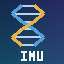

JPEG: 1513 byte | 가닥: 135
총 염기: 19980 nt


In [9]:
try:
    from google.colab import files
except ImportError:
    files = None

uploaded = files.upload() if files is not None else {}
if uploaded:
    image_path = Path(next(iter(uploaded)))
else:
    sample_candidates = [module_path.parent / "samples" / "sample_photo.jpg",
                         module_path.parent.parent / "samples" / "sample_photo.jpg"]
    image_path = next((p for p in sample_candidates if p.exists()),
                      sample_candidates[0])
    if not image_path.exists():
        image_path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(BASE_URL + "samples/sample_photo.jpg", image_path)

image_data = ds.image_bytes(image_path, max_side=64, quality=60, gray=False)
whiten = False  # True로 바꾸면 헤더 외 행에 whitening을 적용한다.
photo_oligos = ds.encode(image_data, dtype="image", ext="jpg", whiten=whiten)
(output_dir / "photo.fasta").write_text(ds.to_fasta(photo_oligos), encoding="utf-8")
display(Image.open(BytesIO(image_data)))
print("JPEG:", len(image_data), "byte | 가닥:", len(photo_oligos))
print("총 염기:", sum(len(item[2]) for item in photo_oligos), "nt")

## 10. 채널 시뮬레이션
- 고정 seed의 LCG를 사용한다. coverage는 가닥당 평균 read 수이다.
- 가닥 소실, 염기 치환·삽입·결실, 역방향 read를 만든다. `drop=[1]`로 헤더 소실을 따로 시험할 수 있다.
- [채널 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#channel)

In [10]:
channel = dict(seed=1, coverage=10, p_drop=0.02, p_sub=0.01,
               p_ins=0.002, p_del=0.002, p_rc=0.5, drop=(), shuffle=True)
reads = ds.simulate([item[2] for item in photo_oligos], **channel)
fastq = "".join(f"@read_{i}\n{seq}\n+\n{'I' * len(seq)}\n"
                for i, seq in enumerate(reads, 1))
(output_dir / "reads.fastq").write_text(fastq, encoding="utf-8")
print(json.dumps(channel, ensure_ascii=False, indent=2))
print("read 수:", len(reads))
print("첫 read 길이:", len(reads[0]) if reads else 0)
print("\n".join(fastq.splitlines()[:4]))

{
  "seed": 1,
  "coverage": 10,
  "p_drop": 0.02,
  "p_sub": 0.01,
  "p_ins": 0.002,
  "p_del": 0.002,
  "p_rc": 0.5,
  "drop": [],
  "shuffle": true
}
read 수: 1314
첫 read 길이: 150
@read_1
AGCCTTGTGTCCATCAATCCAAATAAAAAAAACCCCCTGCAAAATAGACAAAAAACTAAGTAAGGAAGCAAGGAAGAAAACTAAGCAAGGAAAAAAACGAGTCATCTACGGCATTCGCCTCGCGCAATTGTGCGCTATGGTTTGGCTAAT
+
IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII


## 11. 복호 ① · 읽기, 방향, PrimerSort
- 원본 `ReverseEvert → PrimerSort` 순서로 방향을 고르고 프라이머를 검사한다.
- R 프라이머를 고정 위치에서 검사한다. 위치가 밀린 삽입·결실 read는 대개 탈락한다.
- [복호 개요](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#dec-overview)

In [11]:
def reverse_complement(sequence):
    """원본 ReverseEvert 대응: 염기를 상보 치환하고 순서를 뒤집는다."""
    return sequence.translate(str.maketrans("ATGCN", "TACGN"))[::-1]


def matches(left, right):
    """원본 PrimerSort 대응: 같은 위치의 염기 일치 수를 센다."""
    return sum(a == b for a, b in zip(left, right))


loaded_reads = ds.read_sequences(fastq)
counts = dict(reversed=0, no_primer=0, bad_length=0)
bodies = []
body_end = len(F) + 108
oligo_length = body_end + len(R)
for read in loaded_reads:
    if matches(read[:len(F)], F) < len(F) - 2:
        read = reverse_complement(read)
        if matches(read[:len(F)], F) < len(F) - 2:
            counts["no_primer"] += 1
            continue
        counts["reversed"] += 1
    if len(read) < oligo_length or matches(read[body_end:oligo_length], R) < len(R) - 2:
        counts["bad_length"] += 1
        continue
    bodies.append(read[len(F):body_end])
print("전체 read:", len(loaded_reads), "| 본문 통과:", len(bodies))
print(counts)

전체 read: 1314 | 본문 통과: 758
{'reversed': 612, 'no_primer': 87, 'bad_length': 469}


## 12. 복호 ② · iSCAN과 consensus
- 원본 `Consensus2 → Binarization`에 대응한다. 먼저 본문 69–76번 nt에서 index를 읽어 묶는다.
- 같은 index의 각 위치에서 최빈 염기를 고른다. 동률 순서는 A, T, G, C이다.
- index를 RS 정정하기 전에 묶으므로 index 치환은 다른 묶음으로 분류될 수 있다.

In [12]:
groups = defaultdict(list)
for body in bodies:
    index = int.from_bytes(dna_byte(body[68:76]), "big")
    if 1 <= index <= 65535:
        groups[index].append(body)
consensuses = {}
for index, group in groups.items():
    consensuses[index] = "".join(
        max(BASES, key=[body[pos] for body in group].count)
        for pos in range(108))
print("index 묶음 수:", len(groups))
print("처음 8개 묶음의 (index, depth):",
      [(i, len(groups[i])) for i in sorted(groups)[:8]])

index 묶음 수: 180
처음 8개 묶음의 (index, depth): [(1, 3), (2, 8), (3, 6), (4, 9), (5, 8), (6, 3), (7, 5), (8, 7)]


## 13. 복호 ③ · Global RS, Local RS
- Global RS: 묶음의 consensus 부호어를 정정하고, 정정된 index가 묶음 index와 같은지 확인한다.
- Local RS: 실패한 묶음의 개별 read를 정정한 뒤 byte별 최빈값을 고른다.
- [RS 복호 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#dec-rs)

In [13]:
def corrected_row(body, expected_index):
    """원본 RSdecoding 대응: RS 통과와 index 일치를 함께 확인한다."""
    result = ds.rs_decode(dna_byte(body), NSYM)
    if result is None:
        return None
    message, corrected = result
    if int.from_bytes(message[17:19], "big") != expected_index:
        return None
    return message[:17]


recovered_rows, row_sources = {}, {}
failed_groups = []
for index in sorted(groups):
    row = corrected_row(consensuses[index], index)
    if row is None:
        failed_groups.append(index)
    else:
        recovered_rows[index] = row
        row_sources[index] = "global"
for index in failed_groups:
    candidates = [corrected_row(body, index) for body in groups[index]]
    candidates = [row for row in candidates if row is not None]
    if candidates:
        row = bytes(min(Counter(row[pos] for row in candidates).items(),
                        key=lambda item: (-item[1], item[0]))[0]
                    for pos in range(17))
        recovered_rows[index] = row
        row_sources[index] = "local"
print("Global/Local 확보:", dict(Counter(row_sources.values())))
print("RS 이후 행 수:", len(recovered_rows))

Global/Local 확보: {'global': 122, 'local': 6}
RS 이후 행 수: 128


## 14. 복호 ④ · XOR와 헤더
- 원본 `XORrun`에 대응한다. `(j, j+H, D+j)`에서 하나만 없을 때 복원한다.
- 헤더가 없으면 최대 index로 H를 추정한다. XOR로 헤더를 얻으면 D를 다시 읽는다.
- [XOR 복호 설명](https://bbl.stdbioelec.com/courses/molecular-information-engineering/week04/dna-storage/guide.html#dec-xor)

In [14]:
def data_row_count(rows_found):
    """원본 KeyFind 대응: DNAS-1 헤더의 D 또는 최대 index를 읽는다."""
    if 1 in rows_found:
        assert rows_found[1][0] == 1, "지원하지 않는 헤더 version"
        return int.from_bytes(rows_found[1][10:12], "big")
    return 2 * ((max(rows_found, default=0) + 2) // 3)


for pass_number in range(2):
    photo_D = data_row_count(recovered_rows)
    photo_H = photo_D // 2
    for j in range(1, photo_H + 1):
        triplet = (j, j + photo_H, photo_D + j)
        missing = [i for i in triplet if i not in recovered_rows]
        if len(missing) == 1:
            present = [i for i in triplet if i in recovered_rows]
            recovered_rows[missing[0]] = bytes(
                a ^ b for a, b in zip(recovered_rows[present[0]],
                                     recovered_rows[present[1]]))
            row_sources[missing[0]] = "xor"
print("행 확보 경로:", dict(Counter(row_sources.values())))
if 1 in recovered_rows:
    header = recovered_rows[1]
    print("헤더:", dict(version=header[0], type=header[1],
          L=int.from_bytes(header[2:6], "big"),
          crc32=f"{int.from_bytes(header[6:10], 'big'):08X}",
          D=int.from_bytes(header[10:12], "big"), flags=header[12],
          ext=header[13:17].decode("ascii").strip()))
else:
    print("헤더 복원 실패: 파일 길이와 CRC를 확인할 수 없음")

행 확보 경로: {'global': 122, 'local': 6, 'xor': 7}
헤더: {'version': 1, 'type': 2, 'L': 1513, 'crc32': 'EA1DDD9D', 'D': 90, 'flags': 0, 'ext': 'jpg'}


## 15. 복호 ⑤ · 파일 byte와 CRC-32
- 헤더의 길이만큼 byte를 꺼내고 CRC-32와 SHA-256을 확인한다.
- whitening을 켰다면 헤더를 제외한 데이터 행에서 같은 LCG 마스크를 XOR해 해제한다.
- 두 행 소실로 일부 행이 비어 있으면 부분 복원 결과를 반환하며 CRC는 불일치할 수 있다.

In [15]:
restored, restored_header, report = ds.decode(loaded_reads)
print(json.dumps({k: v for k, v in report.items() if k != "status"},
                 ensure_ascii=False, indent=2))
print("가닥 상태:", dict(Counter(report["status"])))
print("원본과 byte 일치:", restored == image_data)
print("직접 계산한 방향/PrimerSort 수치:", counts)
for key, value in counts.items():
    assert report[key] == value
# 단계별 RS·XOR 결과를 공개 decode의 결과와 비교한다.
if 1 in recovered_rows:
    header = recovered_rows[1]
    photo_D = int.from_bytes(header[10:12], "big")
    unpacked = []
    for r in range(2, photo_D + 1):
        row = recovered_rows.get(r, bytes(17))
        if header[12] & 1:
            x, mask = r, []
            for _ in range(17):
                x = (1664525 * x + 1013904223) & 0xFFFFFFFF
                mask.append(x >> 24)
            row = bytes(a ^ b for a, b in zip(row, mask))
        unpacked.append(row)
    manual_bytes = b"".join(unpacked)[:int.from_bytes(header[2:6], "big")]
    assert manual_bytes == restored
    print("단계별 복호 = decode 결과:", True)
(output_dir / "restored_photo.jpg").write_bytes(restored)

{
  "reads": 1314,
  "reversed": 612,
  "no_primer": 87,
  "bad_length": 469,
  "invalid_index": 0,
  "groups": 180,
  "expected": 135,
  "global": 122,
  "local": 6,
  "xor": 7,
  "missing": [],
  "crc_ok": true,
  "type": 2,
  "ext": "jpg",
  "length": 1513,
  "sha256": "22871292410b86619c39b6298d0f7893a7c73da93c714e10b1e5ec59279a6630"
}
가닥 상태: {'global': 122, 'local': 6, 'xor': 7}
원본과 byte 일치: True
직접 계산한 방향/PrimerSort 수치: {'reversed': 612, 'no_primer': 87, 'bad_length': 469}
단계별 복호 = decode 결과: True


1513

## 16. 복원 사진 표시
- 원본과 복원 JPEG를 각각 표시한다. CRC가 맞으면 파일 byte가 같은지 함께 확인한다.
- 손상이 큰 채널에서는 JPEG 표시가 실패할 수 있다. 그때에도 복호 보고와 부분 복원 파일을 확인한다.

축소 JPEG 원본


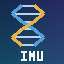

DNA에서 복원한 JPEG


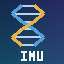

복원 파일: lab_output/restored_photo.jpg


In [16]:
print("축소 JPEG 원본")
display(Image.open(BytesIO(image_data)))
print("DNA에서 복원한 JPEG")
try:
    restored_image = Image.open(BytesIO(restored))
    restored_image.load()
    display(restored_image)
except (OSError, ValueError) as error:
    print("JPEG 표시 실패:", str(error))
print("복원 파일: lab_output/restored_photo.jpg")

## 17. 비교 실험 · seed를 바꾸면 복원에 실패할 수도 있다
- 위의 기본 `seed=1`은 복원 사진을 확인하는 사례이다. 같은 오류율로 `seed=7`을 실제 계산해 비교한다.
- 이 예제 JPEG와 seed 7에서는 동일 XOR 묶음에서 두 데이터 행이 없어진다. XOR로 둘을 결정할 수 없어 CRC가 불일치한다.
- 특정 오류율이 항상 복원을 보장하지 않는다. 아래 수치는 매 실행에서 계산하며, 사진을 바꾸면 결과도 달라진다.

In [17]:
failed_channel = dict(channel, seed=7)
comparison_reads = ds.simulate([item[2] for item in photo_oligos],
                               **failed_channel)
comparison_data, comparison_header, comparison_report = ds.decode(comparison_reads)
print("seed =", failed_channel["seed"])
print(json.dumps({k: v for k, v in comparison_report.items() if k != "status"},
                 ensure_ascii=False, indent=2))
print("원본과 byte 일치:", comparison_data == image_data)
if comparison_header:
    comparison_D = comparison_header["D"]
    comparison_H = comparison_D // 2
    lost = set(comparison_report["missing"])
    for j in range(1, comparison_H + 1):
        triplet = (j, j + comparison_H, comparison_D + j)
        if len(lost.intersection(triplet)) >= 2:
            print("두 행 이상 없는 XOR 묶음:", triplet,
                  "| 없는 행:", sorted(lost.intersection(triplet)))

seed = 7
{
  "reads": 1290,
  "reversed": 602,
  "no_primer": 91,
  "bad_length": 467,
  "invalid_index": 0,
  "groups": 177,
  "expected": 135,
  "global": 124,
  "local": 2,
  "xor": 7,
  "missing": [
    26,
    71
  ],
  "crc_ok": false,
  "type": 2,
  "ext": "jpg",
  "length": 1513,
  "sha256": "a1523e85e541701396411d43683a6e2a84f21b54ff98a3125293d2efccb63cdf"
}
원본과 byte 일치: False
두 행 이상 없는 XOR 묶음: (26, 71, 116) | 없는 행: [26, 71]
